# Prueba Intertrimestral

**Nombre: Fernando** 

**Apellidos: Urrutia Gómez-Menor**  

**Tiempo de la prueba:** 2 horas  
**Asignatura:** Desarrollo de Aplicaciones para la Visualización de Datos  
**Fecha:** 16 de octubre de 2025  

## Instrucciones

- Escribe **código limpio y autoexplicativo**.  
- Se pueden utilizar **los materiales de clase**.  
- Se puede utilizar **internet** para búsqueda de dudas y documentación.  
- **No se puede utilizar ningún tipo de LLM** (ChatGPT, Copilot, Gemini, etc.).  
- **No se puede utilizar mensajería instantánea**.  
- Al finalizar, **sube tu notebook a GitHub** y envía el enlace del fichero en el siguiente formulario:  
[https://forms.office.com/e/LFVwu9z6uQ](https://forms.office.com/e/LFVwu9z6uQ)


## Dataset “Life Style Data”

El dataset contiene información sobre hábitos de vida (alimentación, sueño, ejercicio, consumo de tabaco o alcohol, etc.) y medidas de salud (IMC, presión arterial, etc.) para diferentes individuos.

Puedes descargarlo del repositorio de la asignatura y un .txt con la descripción de las variables.


## Inicialización de librerías

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix


# Ejercicio 1 — Programación (2 puntos)

a) (0.6 pts) Crea una función imc(weight, height) que devuelva el índice de masa corporal (IMC), redondeado a dos decimales.



In [3]:
def imc(weight, height):
    return round(weight/(height**2), 2)


b) (0.6 pts) Crea una función saludable(imcValue) que devuelva "Saludable" si el IMC está entre 18.5 y 24.9, "Bajo peso" si es menor de 18.5, o "Sobrepeso" si es mayor de 24.9.

In [4]:
def saludable(imcValue):
    if imcValue < 18.5:
        return "Bajo peso"
    elif imcValue <= 24.9:
        return "Saludable"
    else:
        return "Sobrepeso"


c) (0.6 pts) Genera un DataFrame llamado imcData que contenga al menos 10 registros con las siguientes columnas:


*   peso (en kilogramos)

*   altura (en metros)

*   imc (calculado usando la función imc(weight, height) creada anteriormente)

Puedes generar los datos de peso y altura manualmente, mediante listas, o de forma aleatoria utilizando numpy (np.random.uniform o similar).

Añade una cuarta columna llamada categoria, cuyos valores provengan de la función saludable(imcValue).

Muestra las primeras filas del DataFrame resultante y comprueba que los tipos de datos son correctos.

In [8]:
np.random.seed(0)

#Así funciona -> random.uniform(low=0.0, high=1.0, size=None)
pesos = np.random.uniform(50.0, 120.0, 10)
alturas = np.random.uniform(1.5, 2.1, 10)
imcs = [imc(p, a) for p, a in zip(pesos, alturas)]
categorias = [saludable(i) for i in imcs]

imcData = pd.DataFrame({
    "Peso": pesos,
    "Altura": alturas,
    "IMC": imcs,
    "Categoria": categorias
})

print(imcData.head())
print(imcData.dtypes)

         Peso    Altura    IMC  Categoria
0   88.416945  1.975035  22.67  Saludable
1  100.063256  1.817337  30.30  Sobrepeso
2   92.193436  1.840827  27.21  Sobrepeso
3   88.141823  2.055358  20.86  Saludable
4   79.655836  1.542622  33.47  Sobrepeso
Peso         float64
Altura       float64
IMC          float64
Categoria     object
dtype: object


d) (0.2 pts) ¿Cómo podrías integrar ambas funciones dentro de una clase llamada HealthTools que calcule el IMC y clasifique automáticamente a partir de listas de pesos y alturas?

In [ ]:
class HealthTools:
    
    def __init__(self, pesos, alturas):
        self.pesos = pesos
        self.alturas = alturas

    #Función a)
    def imc(self, peso, altura):
        return round(peso / (altura ** 2), 2)

    #Función b)
    def saludable(self, imcValue):
        if imcValue < 18.5:
            return "Bajo peso"
        elif imcValue <= 24.9:
            return "Saludable"
        else:
            return "Sobrepeso"

    def clasificar(self):
        imcs = [self.imc(p, a) for p, a in zip(self.pesos, self.alturas)]
        categorias = [self.saludable(i) for i in imcs]
        df = pd.DataFrame({
            "Peso": self.pesos,
            "Altura": self.alturas,
            "IMC": imcs,
            "Categoria": categorias
        })
        return df

np.random.seed(0)
pesos = np.random.uniform(50.0, 120.0, 10)
alturas = np.random.uniform(1.5, 2.1, 10)
imcs = [imc(p, h) for p, h in zip(pesos, alturas)]
categorias = [saludable(i) for i in imcs]

ht = HealthTools(pesos, alturas)
imcData = ht.clasificar()
print(imcData.head())


         Peso    Altura    IMC  Categoria
0   88.416945  1.975035  22.67  Saludable
1  100.063256  1.817337  30.30  Sobrepeso
2   92.193436  1.840827  27.21  Sobrepeso
3   88.141823  2.055358  20.86  Saludable
4   79.655836  1.542622  33.47  Sobrepeso


## Ejercicio 2 — Exploración y visualización (3 puntos)

a) (0.75 pts) Carga el dataset desde el fichero CSV y guárdalo en un DataFrame llamado lifeStyleData. Muestra las 5 primeras filas, el número de filas y columnas.

In [14]:
lifeStyleData = pd.read_csv("Final_data.csv")

print(lifeStyleData.head(5))
print("Número de filas y columnas es: ", lifeStyleData.shape)


     Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0  34.91    Male        65.27        1.62   188.58   157.65        69.05   
1  23.37  Female        56.41        1.55   179.43   131.75        73.18   
2  33.20  Female        58.98        1.67   175.04   123.95        54.96   
3  38.69  Female        93.78        1.70   191.21   155.10        50.07   
4  45.09    Male        52.42        1.88   193.58   152.88        70.84   

   Session_Duration (hours)  Calories_Burned Workout_Type  ...  \
0                      1.00          1080.90     Strength  ...   
1                      1.37          1809.91         HIIT  ...   
2                      0.91           802.26       Cardio  ...   
3                      1.10          1450.79         HIIT  ...   
4                      1.08          1166.40     Strength  ...   

   cal_from_macros  pct_carbs  protein_per_kg   pct_HRR  pct_maxHR  \
0          2139.59   0.500432        1.624789  0.741237   0.835985   
1     

b) (0.75 pts) Crea una función describeData(dataFrame) que devuelva para cada columna: tipo de dato, número de valores nulos y porcentaje de nulos.

In [24]:
def describeData(dataFrame):

    info_col = pd.DataFrame({
        "Tipo": dataFrame.dtypes,
        "Nulos": dataFrame.isnull().sum(),
        "%Nulos": dataFrame.isnull().mean() * 100
    })

    return info_col


c) (0.75 pts) Usa describeData(lifeStyleData) y comenta brevemente (2–3 líneas) qué variables parecen tener más valores faltantes.

In [25]:
describeData(lifeStyleData)

,Tipo,Nulos,%Nulos
Age,float64,0,0.000
Gender,object,0,0.000
Weight (kg),float64,0,0.000
Height (m),float64,0,0.000
Max_BPM,float64,1,0.005
Avg_BPM,float64,1,0.005
Resting_BPM,float64,0,0.000
Session_Duration (hours),float64,0,0.000
Calories_Burned,float64,0,0.000
Workout_Type,object,0,0.000


No parece que existan demasiados valores nulos a excepción de 1 en las columnas:
- Max_BPM
- Av_BPM
- cholesterol_mg

d) (0.75 pts) Realiza un gráfico que muestre las correlaciones entre variables numéricas. ¿Hay alguna correlación fuerte o inesperada?

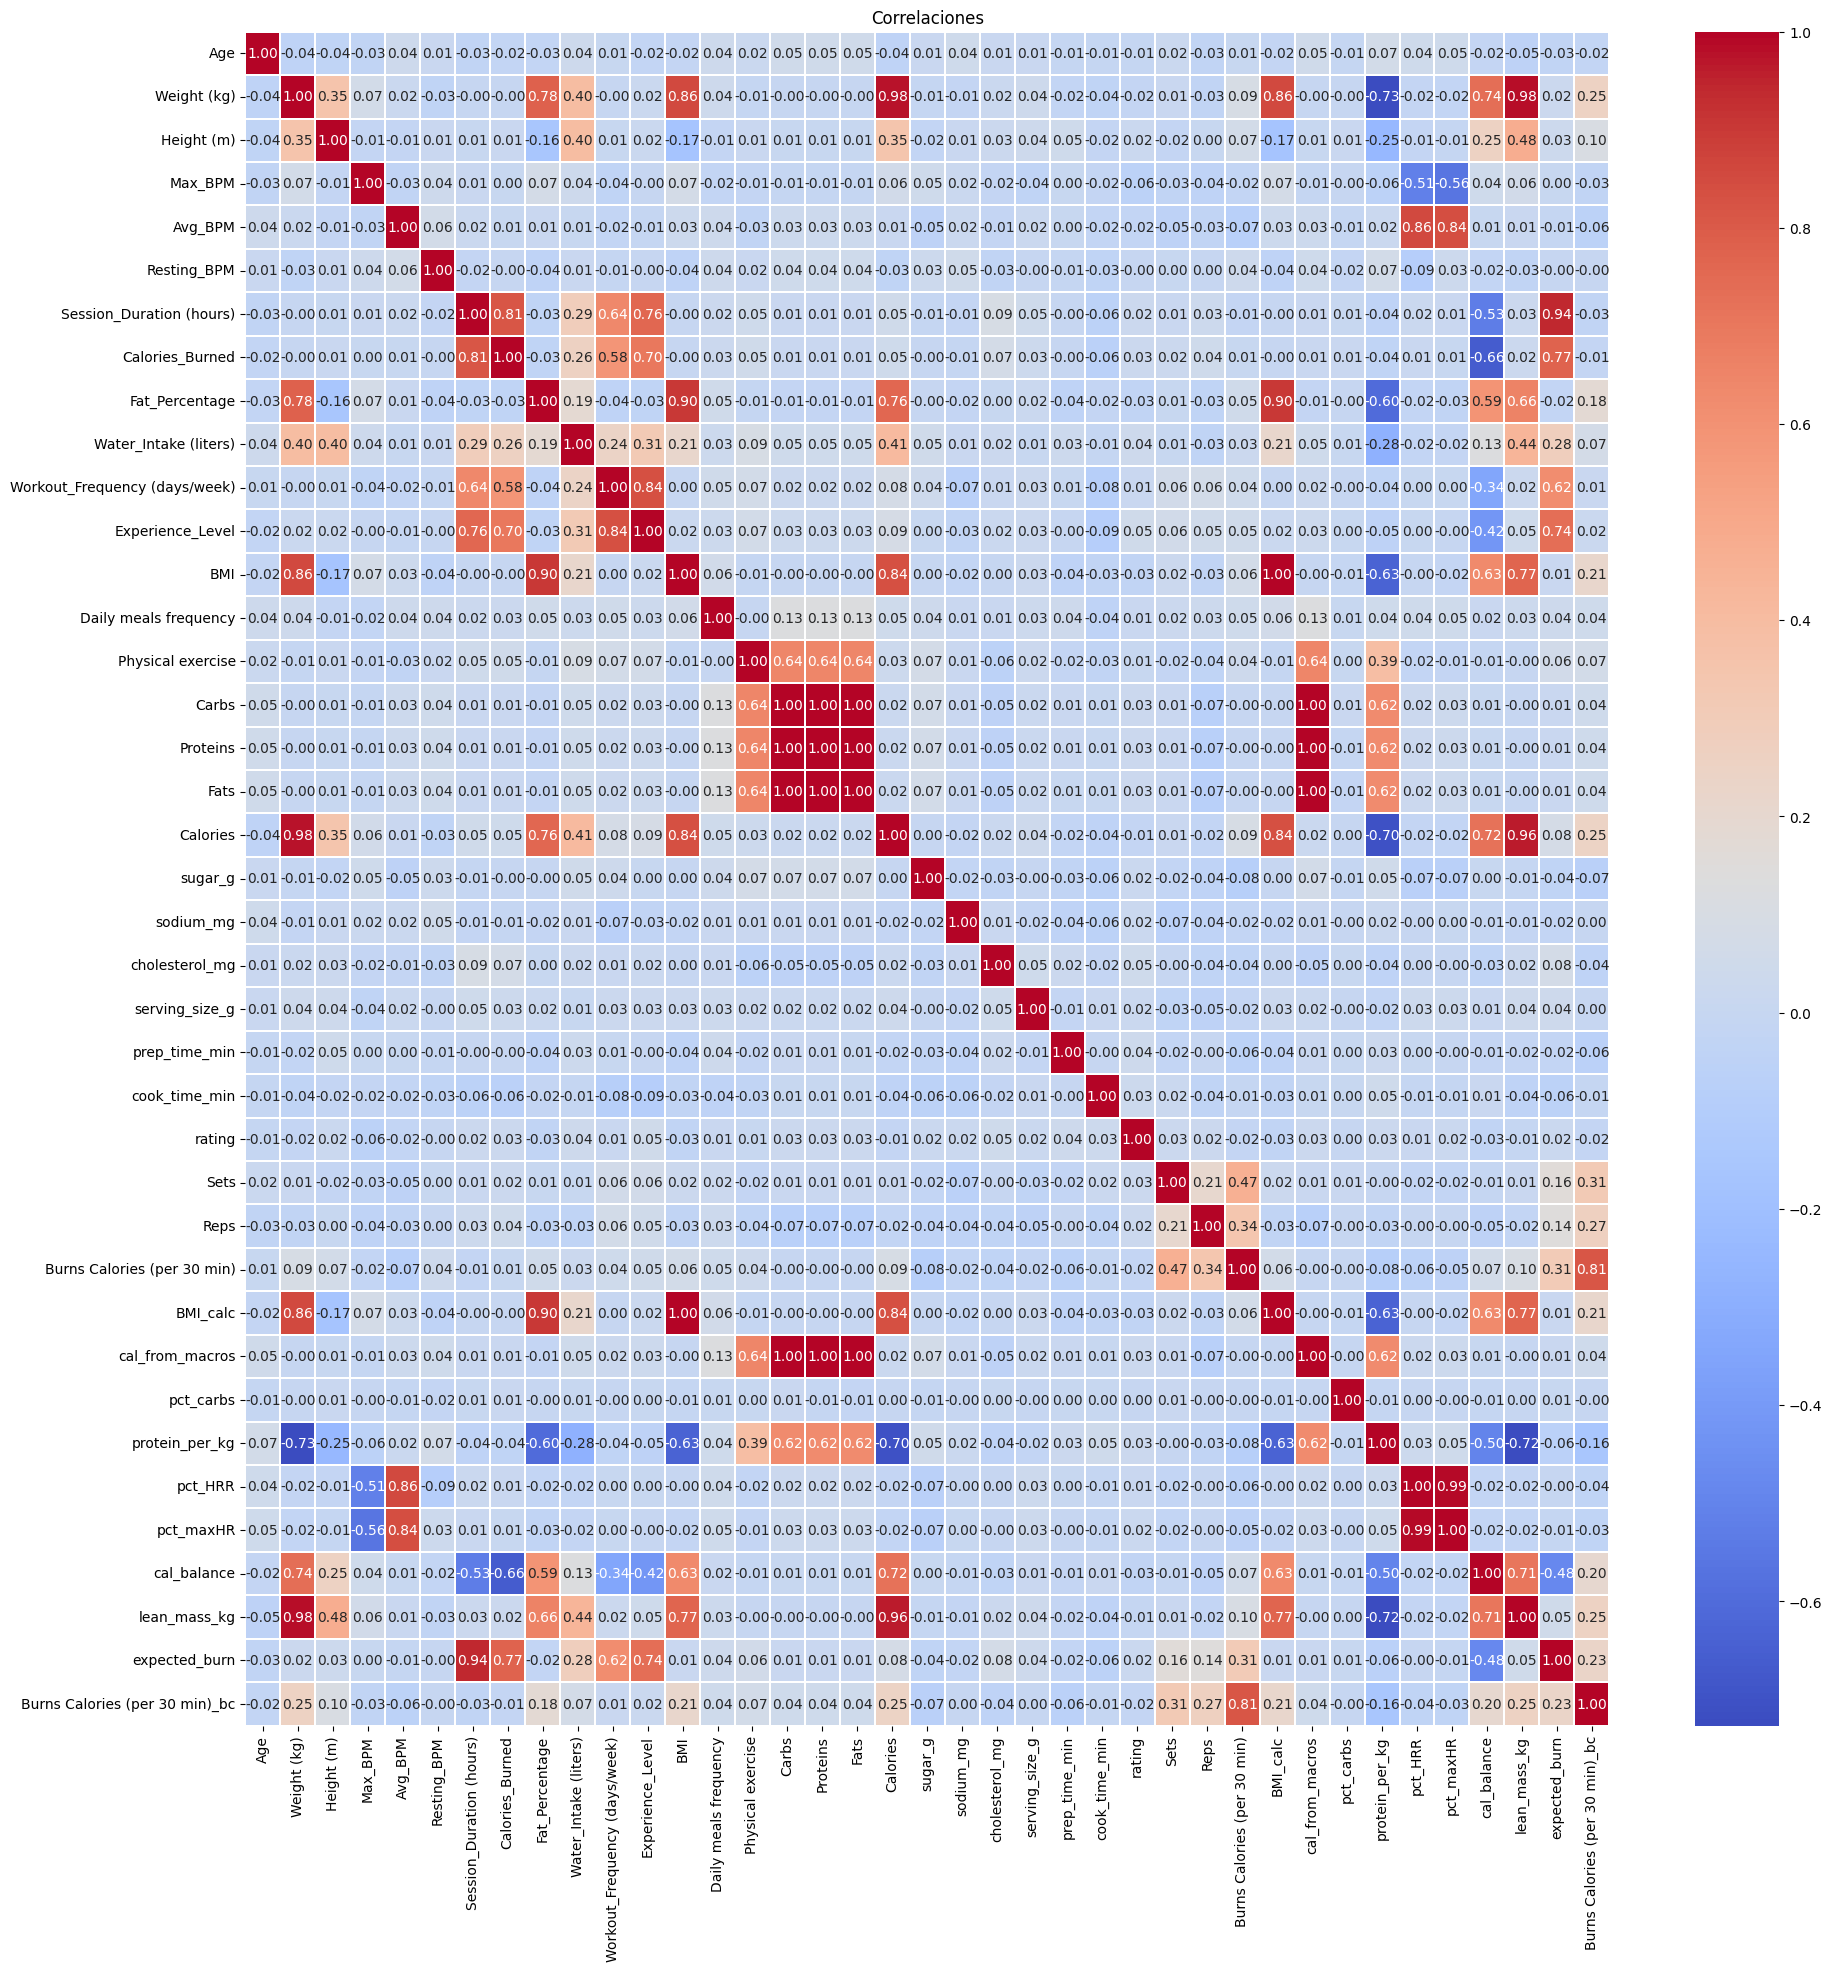

In [36]:
matriz_correlaciones = lifeStyleData.corr(numeric_only=True)

plt.figure(figsize=(22, 22))
sns.heatmap(matriz_correlaciones, annot=True, cmap='coolwarm', fmt=".2f", linewidth=.3)
plt.title('Correlaciones')
plt.show()


Observaciones:
- La altura parece no importar tanto para el calculo del BMI en comparación con el peso. Esto puede inferirse también de la fórmula, pero aquí se comprueba
- Experience level y expected burn parecen muy correladas (0,7). De aquí infiero que cuanto mejor deportista o experimentado es la persona, más calorías quema. Es decir, realizar mejor los ejercicios hace que el trabajo sea más fructífero
- Cuantas más calorías menos proteínas por kg hay (correlación negativa aprox 0,7)

## Ejercicio 3 — Regresión básica (2 puntos)

Queremos predecir una variable de salud continua, por ejemplo bmi.

a) (0.25 pts) Define targetVar = "bmi" y selecciona 2–3 variables predictoras (por ejemplo sleepHours, activityLevel, calories). Guarda las columnas predictoras en X y la variable objetivo en y.

In [ ]:
X = lifeStyleData[['Fat_Percentage','Calories','protein_per_kg','lean_mass_kg']]
targetVar = lifeStyleData[['BMI']]
y = targetVar

b) (0.25 pts) Divide los datos en entrenamiento (70 %) y prueba (30 %).

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 123)

c) (0.75 pts) Entrena un modelo de regresión lineal (LinearRegression) y calcula el R² y el MSE.

Coefficients: 
 [[0.87935891 0.00241469 0.13391105 0.08277771]]
Mean squared error: 6.02
Coefficient of determination: 0.87


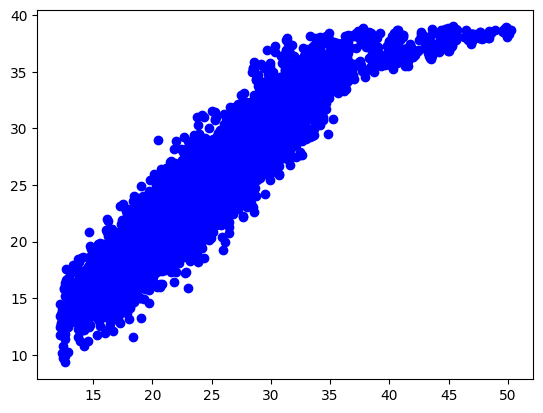

In [52]:
model_reg = LinearRegression().fit(X_train, y_train)

y_pred = model_reg.predict(X_test)

#Coeficientes
print("Coefficients: \n", model_reg.coef_)
#MSE
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
#R2
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

# Plot outputs
plt.scatter(y_test, y_pred, color="blue")

plt.show()

d) (0.75 pts) Entrena un RandomForestRegressor con los mismos datos y compara resultados. ¿Cuál tiene mejor rendimiento?

c:\Users\ferch\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


Coefficients: 
 [[0.87935891 0.00241469 0.13391105 0.08277771]]
Mean squared error: 8.72
Coefficient of determination: 0.81


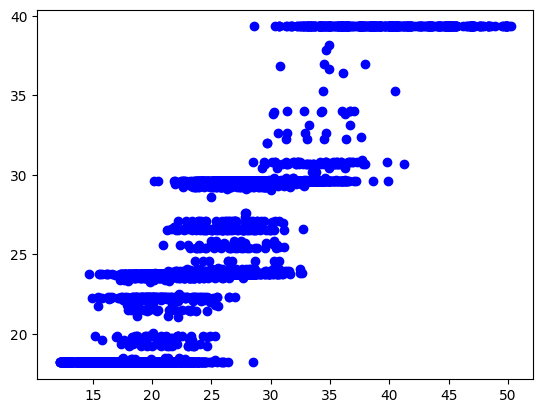

In [55]:
model_random = RandomForestRegressor(max_depth=2, random_state=0).fit(X_train, y_train)

y_pred = model_random.predict(X_test)

#Coeficientes
print("Coefficients: \n", model_reg.coef_)
#MSE
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
#R2
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

# Plot outputs
plt.scatter(y_test, y_pred, color="blue")

plt.show()

##### RESULTADOS
------------------------------------
-> Linear Regression
Coefficients: 
 [[0.87935891 0.00241469 0.13391105 0.08277771]]
Mean squared error: 6.02
Coefficient of determination: 0.87

--> RandomForestRegressor
Coefficients: 
 [[0.87935891 0.00241469 0.13391105 0.08277771]]
Mean squared error: 8.72
Coefficient of determination: 0.81

##### CONCLUSIONES
-------------------------------------
- Con las variables predictoras escogidas, una regresión lineal parece ser mejor modelo 
para tratar de hallar el BMI (mejor R2 y menos error). Mejor rendimiento

## Ejercicio 4 — Clasificación sencilla (2 puntos)

Crea una nueva variable binaria que indique si el IMC está dentro del rango saludable.

a) (0.25 pts) Crea una nueva columna bmiHealthy donde el valor sea 1 si bmi está entre 18.5 y 24.9, y 0 en caso contrario.

In [ ]:
lifeStyleData["bmiHealthy"] = lifeStyleData.apply(lambda x: 1 if ((x['BMI']>=18.5)&(x['BMI']<=24.9)) else 0, axis=1)

b) (0.75 pts) Entrena un modelo de regresión logística (LogisticRegression) para predecir bmiHealthy usando algunas variables de estilo de vida (por ejemplo sleepHours, activityLevel, calories).

In [65]:
X = lifeStyleData[['Fat_Percentage','Calories','protein_per_kg','lean_mass_kg']]
y = lifeStyleData[['bmiHealthy']]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 123)

model_log = LogisticRegression(max_iter=10000, tol=0.1).fit(X_train, y_train)

y_pred = model_log.predict(X_test)

#Coeficientes
print("Coefficients: \n", model_log.coef_)
#MSE
print("Mean squared error: %.2f" % mean_squared_error(y_test, y_pred))
#R2
print("Coefficient of determination: %.2f" % r2_score(y_test, y_pred))

# Plot outputs
#plt.scatter(y_test, y_pred, color="blue")
#plt.show()

Coefficients: 
 [[ 0.00563372 -0.00384435  0.01604564  0.13059837]]
Mean squared error: 0.38
Coefficient of determination: -0.63


c:\Users\ferch\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


c) (0.25 pts) Calcula la exactitud (accuracy) del modelo y muestra la matriz de confusión.


In [73]:
print("Classification report")
print(accuracy_score(y_test, y_pred))

print("Confusion matrix")
print(confusion_matrix(y_test, y_pred))

Classification report
0.616
Confusion matrix
[[3156  567]
 [1737  540]]


d) (0.75 pts) Explica qué variable parece influir más según el modelo.

Por los coeficientes vistos en el apartado b, la variable que parece influir más (será aquella con el valor absoluto de coeficiente más alto) es lean_mass_kg (grasas por kilogramo)

## Ejercicio 5 — Conclusión (1 punto)

En un máximo de 300 palabras, resume:

*   Qué hábitos parecen tener mayor relación con el estado de salud.

*   Qué modelo fue más eficaz y por qué.

*   Qué podrías mejorar si tuvieras más tiempo o datos.



Los hábitos más relacionados con el estado de la salud son los relativos a realizar un buen ejercicio (experiencia, frecuencia del ejercicio) y aquellos relacionados con la alimentación: proteínas, calorías, grasas bajas, ingesta de agua...


El modelo más eficaz fue la regresión lineal aunque el random forest también obtiene buenos resultados.
Por el R2 negativo de la regresión logística entiendo que discenir de forma binaria si una persona es saludable o no es complicado (eso o que hay algo mal afectando al modelo ya que un R2 negativo es extraño). La salud puede tener muchos grises y una persona con todas las características favorables a un buen estado de salud, no estarlo. O viceversa.

En sí una muestra poblacional de 20000 sujetos es un buen punto de partida para realizar un análisis como este. Más datos lo único que serviría es para pulir o perfeccionar el accuracy de los modelos. Con más tiempo se podrían aplicar otros modelos o implementar una red neuronal que sea capaz de determinar en tiempo real (o casi) si hay riesgos de salud dependiendo de la actividad, alimentación, sueño y demás factores que afectan al estado físico de las personas.

- Fernando Urrutia